# **Churn Prediction ML Pipeline**

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

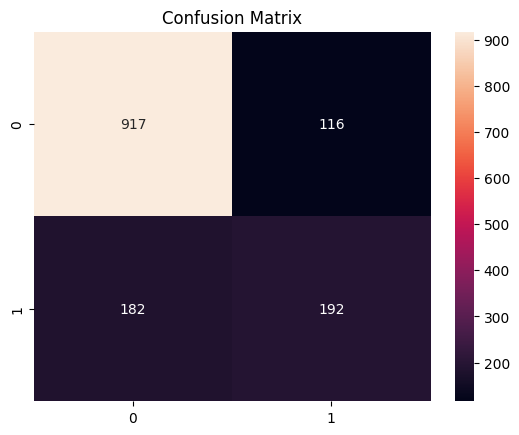

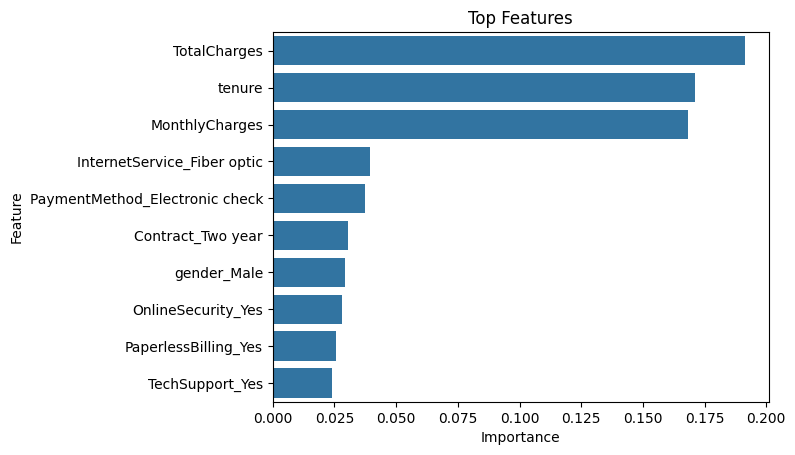

Pipeline Completed Successfully


In [7]:
# 1. IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle

# 2. LOAD DATA
df = pd.read_csv("Telco-Customer-Churn.csv")

#3.  BASIC INFO
print(df.shape)
df.info()
df.isnull().sum()

# 3. DATA CLEANING
df.drop("customerID", axis=1, inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.dropna(inplace=True)

# 4. TARGET ENCODING
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# 5. FEATURE ENGINEERING
df = pd.get_dummies(df, drop_first=True)

# 6. SPLIT
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 8. MODEL
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 9. PREDICT
y_pred = model.predict(X_test)

# 10. EVALUATE
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 11. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# 12. FEATURE IMPORTANCE
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top Features")
plt.show()

# 13. SAVE MODEL
pickle.dump(model, open("model.pkl", "wb"))

print("Pipeline Completed Successfully")

In [6]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

def train_model(path):
    df = pd.read_csv(path)

    df.drop("customerID", axis=1, inplace=True)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
    df.dropna(inplace=True)

    df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
    df = pd.get_dummies(df, drop_first=True)

    X = df.drop("Churn", axis=1)
    y = df["Churn"]

    X_train, X_test, y_train, y_test = train_test_split(X, y)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    pickle.dump(model, open("model.pkl", "wb"))
    pickle.dump(scaler, open("scaler.pkl", "wb"))

if __name__ == "__main__":
    train_model("Telco-Customer-Churn.csv")

In [10]:
with open("train.py", "w") as f:
    f.write("""
# paste your train.py code here
""")
